# GP and embedding-system comparison (paper, Appendix A)

Four ways to compute the certified tube, at the **same** certificate: the tube's position bounds within
**0.25 m** of the reference position (and above the 0.3 m floor), position uncertainty $\delta = 0$.

| variant | wind model | embedding system | what the tube accounts for |
|---|---|---|---|
| **A** (current code) | TV-GPR ($\epsilon = 0.25$) | (68)-(69) | first-order interaction of the state with the feedback $u$ **and** the disturbance $w$ |
| **D** (control) | GPR ($\epsilon = 0$) | (68)-(69) | same as A, time-invariant GP: isolates the GP |
| **C** | GPR | (66)-(67) | first order in $u$ only; disturbance bounded over the box $[\underline\gamma, \overline\gamma]$ |
| **B** | GPR | (64)-(65) | no first-order terms: input interval from the feedback law by interval arithmetic, disturbance over the box |

A vs D isolates the **GP** (time-varying vs time-invariant); D vs C vs B isolates the **embedding system**
with the same GP. The GPR is TVGPR with $\epsilon = 0$ (Assumption 2: the temporal kernel is then 1).

**Data.** *Numerical closed loop* (`px4_rta_mm_gpr.sim`, exact state, known wind): calm and the paper's
evolving winds at ×0.3 / ×0.6 / ×1.0 with 3 seeds; the backup is **off**, so every variant flies the full
mission and the certification statistics cover the same task. *PX4 SITL*: 3 flights per variant, the
backup (PX4 LAND after 20 ms without a certified plan) **on**, as deployed.

Tables: best value per column ★, worst ▽.

**Metrics.** `cert_med_s` / `cert_p5_s`: how far ahead each plan is certified (median / 5th percentile);
`plans`: replans in the 20 s phase; `uncertified_pct`: control ticks without a certified plan;
`escape_pct` / `escape_max_m`: certified ticks where the vehicle's position (true state in the numerical
runs, EKF2 estimate in SITL) is **outside** the certified box by more than 1 mm, and the largest excursion;
`tube_halfwidth_025`: tube position half-width 0.25 s into each plan (smaller = tighter);
`rollout_ms_*`: compute time of one rollout.

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
from px4_rta_mm_gpr import analysis as rta
rta.use_style()
pd.set_option('display.width', 220, 'display.max_columns', 40, 'display.precision', 3)
os.makedirs('figures', exist_ok=True)
DATA = 'log_files/comparison'
ORDER = list(rta.VARIANTS)                 # A, D, C, B
SHORT = {v: v.split(':')[0] for v in ORDER}
COLS = ['cert_med_s', 'cert_p5_s', 'plans', 'uncertified_pct', 'escape_pct', 'escape_max_m', 'tube_halfwidth_025',
        'rmse_y', 'rmse_altitude', 'lowest_certified_tube', 'rollout_ms_med', 'rollout_ms_p99']
BETTER = {'cert_med_s': 'max', 'cert_p5_s': 'max', 'plans': 'min', 'uncertified_pct': 'min', 'escape_pct': 'min',
          'escape_max_m': 'min', 'tube_halfwidth_025': 'min', 'rmse_y': 'min', 'rmse_altitude': 'min',
          'lowest_certified_tube': 'max', 'rollout_ms_med': 'min', 'rollout_ms_p99': 'min'}

def styled(df, cols=COLS, fmt='{:.3g}'):
    """Formatted table: best value per column marked ★, worst ▽ (no styling dependency, renders anywhere)."""
    cols = [c for c in cols if c in df.columns]
    out = df[cols].copy().astype(object)
    for c in cols:
        col = df[c].astype(float)
        best = worst = None
        if c in BETTER and not col.isna().all() and col.nunique() > 1:
            best = col.max() if BETTER[c] == 'max' else col.min()
            worst = col.min() if BETTER[c] == 'max' else col.max()
        out[c] = [fmt.format(v) + (' ★' if v == best else (' ▽' if v == worst else '')) if np.isfinite(v) else '-'
                  for v in col]
    return out

## 1. Numerical closed loop (backup off, 10 wind cases per variant)

In [2]:
RUN_SIMS = False   # True: re-run the 40 simulations (deterministic; ~10 min) instead of reading the CSV
if RUN_SIMS:
    from px4_rta_mm_gpr.sim import SimConfig, simulate, paper_winds, calm
    rows = []
    for v, (eps, emb) in rta.VARIANTS.items():
        for case, seed, k in [('calm', 0, None)] + [(f'winds x{k}', s, k) for k in (0.3, 0.6, 1.0) for s in (0, 1, 2)]:
            w = calm() if k is None else paper_winds(scale=2.0 * k, seed=seed)
            path = f"/tmp/cmp_{v[0]}_{case.replace(' ', '')}_{seed}.h5"
            r = simulate(SimConfig(duration=20.0, seed=seed, gp_epsilon=eps, embedding=emb, stop_on_backup=False),
                         winds=w, log_path=path)
            m = rta.comparison_metrics(rta.load(path)); m.update(variant=v, case=case, seed=seed,
                                                                  final_error_to_goal=r.summary['final_error_to_goal'])
            rows.append(m)
    num = pd.DataFrame(rows)
else:
    num = pd.read_csv(f'{DATA}/numerical/numerical_comparison.csv')
num['variant'] = pd.Categorical(num['variant'], ORDER, ordered=True)
print(f"{len(num)} runs; all completed the 20 s mission: {bool((num['uncertified_pct'].notna()).all())}")

40 runs; all completed the 20 s mission: True


### Overall (mean over the 10 wind cases)

In [3]:
overall = num.groupby('variant', observed=True)[COLS].mean()
overall.index = [SHORT[v] + ': ' + v.split(': ')[1] for v in overall.index]
styled(overall)

,cert_med_s,cert_p5_s,plans,uncertified_pct,escape_pct,escape_max_m,tube_halfwidth_025,rmse_y,rmse_altitude,lowest_certified_tube,rollout_ms_med,rollout_ms_p99
A: TV-GPR + (68)-(69),0.594 ▽,0.489,34.6,0,0 ★,0.000476 ★,0.0254 ▽,0.00743 ★,0.00735 ★,1.14 ★,6.91,8.88 ★
D: GPR + (68)-(69),0.803,0.51,25.5 ★,0,36.8 ▽,0.0576,0.00259,0.0192,0.0213,1.1,7.34 ▽,9.67
C: GPR + (66)-(67),0.821 ★,0.511 ★,39.7,0,36.5,0.146,0.00242,0.0296,0.0358,1.08,6.19 ★,10.6 ▽
B: GPR + (64)-(65),0.729,0.464 ▽,43.1 ▽,0,36.5,0.159 ▽,0.00239 ★,0.0328 ▽,0.0367 ▽,1.03 ▽,6.35,9.76


### Relative to A (the current code): ratio of means

In [4]:
rel = overall.div(overall.iloc[0])
styled(rel, fmt='{:.2f}x')

,cert_med_s,cert_p5_s,plans,uncertified_pct,escape_pct,escape_max_m,tube_halfwidth_025,rmse_y,rmse_altitude,lowest_certified_tube,rollout_ms_med,rollout_ms_p99
A: TV-GPR + (68)-(69),1.00x ▽,1.00x,1.00x,-,-,1.00x ★,1.00x ▽,1.00x ★,1.00x ★,1.00x ★,1.00x,1.00x ★
D: GPR + (68)-(69),1.35x,1.04x,0.74x ★,-,-,121.18x,0.10x,2.58x,2.89x,0.96x,1.06x ▽,1.09x
C: GPR + (66)-(67),1.38x ★,1.05x ★,1.15x,-,-,306.21x,0.10x,3.98x,4.87x,0.94x,0.90x ★,1.19x ▽
B: GPR + (64)-(65),1.23x,0.95x ▽,1.25x ▽,-,-,333.49x ▽,0.09x ★,4.41x ▽,5.00x ▽,0.91x ▽,0.92x,1.10x


### By wind strength

In [5]:
num['wind'] = num['case'].str.replace('winds ', 'paper winds ')
by = num.groupby(['wind', 'variant'], observed=True)[['cert_med_s', 'plans', 'uncertified_pct', 'escape_pct',
                                                      'escape_max_m', 'tube_halfwidth_025', 'rmse_y']].mean()
by

cert_med_s   plans  uncertified_pct  escape_pct  escape_max_m  tube_halfwidth_025  rmse_y
wind             variant                                                                                                         
calm             A: TV-GPR + (68)-(69)       0.630  32.000              0.0       0.000     0.000e+00               0.022   0.001
                 D: GPR + (68)-(69)          1.015  16.000              0.0       1.500     3.234e-03               0.002   0.002
                 C: GPR + (66)-(67)          1.015  16.000              0.0       1.500     3.234e-03               0.002   0.002
                 B: GPR + (64)-(65)          1.015  16.000              0.0       1.500     3.298e-03               0.002   0.002
paper winds x0.3 A: TV-GPR + (68)-(69)       0.617  33.333              0.0       0.000     2.005e-04               0.023   0.004
                 D: GPR + (68)-(69)          0.917  22.667              0.0      33.383     3.455e-02               0.002   0.014
                 C: GPR + (66)-(67)          1.025  19.667              0.0      36.133     6.612e-02               0.002   0.025
                 B: GPR + (64)-(65)          0.722  63.000              0.0      35.583     7.844e-02               0.002   0.028
paper winds x0.6 A: TV-GPR + (68)-(69)       0.603  34.333              0.0       0.000     5.033e-04               0.025   0.008
                 D: GPR + (68)-(69)          0.762  26.333              0.0      45.717     7.299e-02               0.003   0.022
                 C: GPR + (66)-(67)          0.593  81.667              0.0      44.383     1.892e-01               0.002   0.025
                 B: GPR + (64)-(65)          0.600  49.333              0.0      40.504     1.917e-01               0.002   0.023
paper winds x1.0 A: TV-GPR + (68)-(69)       0.550  37.000              0.0       0.000     8.818e-04               0.029   0.013
                 D: GPR + (68)-(69)          0.662  30.667              0.0      42.933     8.350e-02               0.003   0.027
                 C: GPR + (66)-(67)          0.780  25.667              0.0      40.683     2.291e-01               0.003   0.048
                 B: GPR + (64)-(65)          0.768  26.000              0.0      45.117     2.575e-01               0.003   0.058

### Isolating the two effects
* **GP effect** (same embedding (68)-(69)): A (TV-GPR) vs D (GPR).
* **Embedding effect** (same GPR): D (68)-(69) vs C (66)-(67) vs B (64)-(65).

In [6]:
effects = pd.DataFrame({
    'GP: D / A': overall.iloc[1] / overall.iloc[0],
    'embedding: C / D': overall.iloc[2] / overall.iloc[1],
    'embedding: B / D': overall.iloc[3] / overall.iloc[1],
}).T[['cert_med_s', 'plans', 'escape_pct', 'escape_max_m', 'tube_halfwidth_025', 'rollout_ms_med']]
effects.map(lambda v: f'{v:.2f}x')

,cert_med_s,plans,escape_pct,escape_max_m,tube_halfwidth_025,rollout_ms_med
GP: D / A,1.35x,0.74x,infx,121.18x,0.10x,1.06x
embedding: C / D,1.02x,1.56x,0.99x,2.53x,0.93x,0.84x
embedding: B / D,0.91x,1.69x,0.99x,2.75x,0.92x,0.86x


### The four tubes from the same start
One plan's inputs (state, gains, GP data) from the ×0.6 wind run, rolled out with each variant: position
half-width of the tube vs look-ahead, against the 0.25 m threshold.

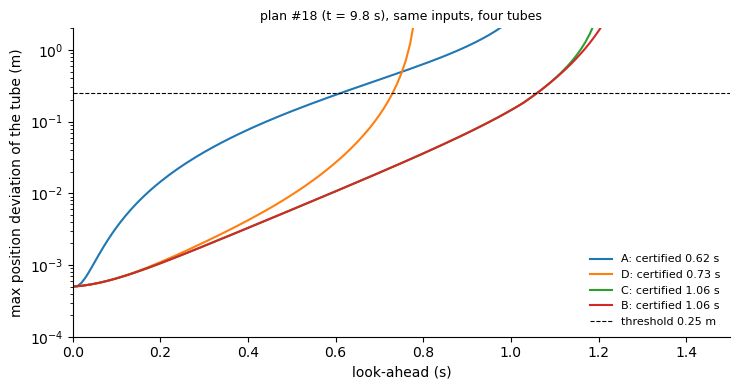

In [7]:
from px4_rta_mm_gpr.concurrency import RolloutConfig, RolloutEngine, RolloutRequest
ref_log = rta.load(sorted(glob.glob(f'{DATA}/numerical/A_windsx0p6_s0.h5'))[0])
md_ = ref_log.metadata
p = ref_log.plan(int(ref_log.plan_seqs[len(ref_log.plan_seqs) // 2]))
fig, ax = plt.subplots(figsize=(7.5, 4))
for v, (eps, emb) in rta.VARIANTS.items():
    eng = RolloutEngine(RolloutConfig(mass=float(md_['mass']), horizon=2.0, timestep=0.01,
                                      ulim_lower=(float(md_['thrust_lo']), -1.0), ulim_upper=(float(md_['thrust_hi']), 1.0),
                                      goal_state=tuple(md_['goal']), x_pert=(5e-4,) * 5, collection_threshold=0.25,
                                      n_obs=9, early_exit=False, min_altitude=0.3, gp_feedforward=True,
                                      gp_epsilon=eps, embedding=emb))
    r = eng.compute(RolloutRequest(t_start=float(p['t_start']), state=p['state0'], K_feedback=p['K_feedback'],
                                   K_reference=p['K_reference'], obs_wy=p['obs_wy'], obs_wz=p['obs_wz'], goal=p['goal']))
    tb, ref = r.reachable_tube, r.rollout_ref
    dev = np.maximum(np.abs(tb[:, 0:2] - ref[:, 0:2]), np.abs(tb[:, 5:7] - ref[:, 0:2])).max(axis=1)
    tt = 0.01 * np.arange(len(dev))
    ax.plot(tt, dev, lw=1.5, label=f"{SHORT[v]}: certified {r.violation_idx * 0.01:.2f} s")
ax.axhline(0.25, color='k', ls='--', lw=0.8, label='threshold 0.25 m')
ax.set_yscale('log'); ax.set_ylim(1e-4, 2); ax.set_xlim(0, 1.5)
ax.set_xlabel('look-ahead (s)'); ax.set_ylabel('max position deviation of the tube (m)')
ax.legend(frameon=False, fontsize=8); ax.set_title(f"plan #{p['seq']} (t = {p['t_start']:.1f} s), same inputs, four tubes", fontsize=9)
fig.tight_layout(); fig.savefig('figures/comparison_tubes.pdf'); fig.savefig('figures/comparison_tubes.png', dpi=150)

## 2. PX4 SITL (backup LAND on; 3 flights per variant)

In [8]:
sitl_logs = sorted(glob.glob(f'{DATA}/sitl/cmp_*.h5'))
rows = []
for f in sitl_logs:
    with rta.load(f) as L:
        m = rta.comparison_metrics(L, os.path.basename(f))
    v = next(k for k in ORDER if k.startswith(os.path.basename(f).split('_')[1] + ':'))
    m['variant'] = v
    rows.append(m)
sitl = pd.DataFrame(rows)
sitl['variant'] = pd.Categorical(sitl['variant'], ORDER, ordered=True)
print(f"{len(sitl)} flights; backups engaged: {int(sitl['backup_at_s'].notna().sum())}")
S_COLS = COLS + ['control_period_p99_ms', 'max_attitude_deg']
BETTER.update(control_period_p99_ms='min', max_attitude_deg='min')
s_overall = sitl.groupby('variant', observed=True)[S_COLS].mean()
s_overall.index = [SHORT[v] + ': ' + v.split(': ')[1] for v in s_overall.index]
styled(s_overall, S_COLS)

12 flights; backups engaged: 0


,cert_med_s,cert_p5_s,plans,uncertified_pct,escape_pct,escape_max_m,tube_halfwidth_025,rmse_y,rmse_altitude,lowest_certified_tube,rollout_ms_med,rollout_ms_p99,control_period_p99_ms,max_attitude_deg
A: TV-GPR + (68)-(69),0.542 ▽,0.42,40.7 ▽,0 ★,19.1 ★,0.112 ★,0.0278 ▽,0.0199 ★,0.027 ★,0.859 ★,9.03,11.2,10.6 ★,28.7 ▽
D: GPR + (68)-(69),0.777,0.408 ▽,21.7,0 ★,64.6,0.211,0.00825,0.0238,0.032,0.745 ▽,10 ▽,15.4 ▽,11.1 ▽,28.3
C: GPR + (66)-(67),0.82,0.503 ★,19.7,0 ★,66.6,0.38 ▽,0.00551,0.027 ▽,0.0421 ▽,0.771,5.14 ★,8.99 ★,10.9,28.5
B: GPR + (64)-(65),0.835 ★,0.5,19.3 ★,0.0343 ▽,71.1 ▽,0.195,0.00315 ★,0.0266,0.0417,0.841,5.34,15.2,10.8,27.8 ★


### Spread over the 3 flights (mean ± std)

In [9]:
g = sitl.groupby('variant', observed=True)[['cert_med_s', 'plans', 'escape_pct', 'escape_max_m', 'rmse_y', 'rmse_altitude']]
ms = g.mean().round(3).astype(str) + ' ± ' + g.std().round(3).astype(str)
ms.index = [SHORT[v] for v in ms.index]
ms

,cert_med_s,plans,escape_pct,escape_max_m,rmse_y,rmse_altitude
A,0.542 ± 0.008,40.667 ± 2.082,19.09 ± 1.726,0.112 ± 0.008,0.02 ± 0.002,0.027 ± 0.002
D,0.777 ± 0.045,21.667 ± 0.577,64.596 ± 1.748,0.211 ± 0.057,0.024 ± 0.001,0.032 ± 0.008
C,0.82 ± 0.036,19.667 ± 1.155,66.567 ± 8.006,0.38 ± 0.364,0.027 ± 0.006,0.042 ± 0.021
B,0.835 ± 0.013,19.333 ± 0.577,71.06 ± 15.876,0.195 ± 0.065,0.027 ± 0.005,0.042 ± 0.011


### Relative to A

In [10]:
styled(s_overall.div(s_overall.iloc[0]), S_COLS, fmt='{:.2f}x')

,cert_med_s,cert_p5_s,plans,uncertified_pct,escape_pct,escape_max_m,tube_halfwidth_025,rmse_y,rmse_altitude,lowest_certified_tube,rollout_ms_med,rollout_ms_p99,control_period_p99_ms,max_attitude_deg
A: TV-GPR + (68)-(69),1.00x ▽,1.00x,1.00x ▽,-,1.00x ★,1.00x ★,1.00x ▽,1.00x ★,1.00x ★,1.00x ★,1.00x,1.00x,1.00x ★,1.00x ▽
D: GPR + (68)-(69),1.43x,0.97x ▽,0.53x,-,3.38x,1.90x,0.30x,1.20x,1.19x,0.87x ▽,1.11x ▽,1.37x ▽,1.05x ▽,0.99x
C: GPR + (66)-(67),1.51x,1.20x ★,0.48x,-,3.49x,3.41x ▽,0.20x,1.36x ▽,1.56x ▽,0.90x,0.57x ★,0.80x ★,1.03x,0.99x
B: GPR + (64)-(65),1.54x ★,1.19x,0.48x ★,-,3.72x ▽,1.75x,0.11x ★,1.34x,1.54x,0.98x,0.59x,1.35x,1.03x,0.97x ★


### Per flight

In [11]:
sitl.sort_values(['variant', 'flight'])[['flight', 'variant', 'cert_med_s', 'plans', 'uncertified_pct', 'escape_pct',
                                         'escape_max_m', 'rmse_y', 'rmse_altitude', 'backup_at_s']]

,flight,variant,cert_med_s,plans,uncertified_pct,escape_pct,escape_max_m,rmse_y,rmse_altitude,backup_at_s
0,cmp_A_1.h5,A: TV-GPR + (68)-(69),0.535,40,0.000,20.850,0.109,0.022,0.029,NaN
1,cmp_A_2.h5,A: TV-GPR + (68)-(69),0.540,39,0.000,17.400,0.120,0.020,0.027,NaN
2,cmp_A_3.h5,A: TV-GPR + (68)-(69),0.550,43,0.000,19.019,0.105,0.018,0.025,NaN
9,cmp_D_1.h5,D: GPR + (68)-(69),0.730,22,0.000,66.000,0.274,0.024,0.040,NaN
10,cmp_D_2.h5,D: GPR + (68)-(69),0.820,21,0.000,65.150,0.163,0.024,0.025,NaN
11,cmp_D_3.h5,D: GPR + (68)-(69),0.780,22,0.000,62.638,0.197,0.023,0.031,NaN
6,cmp_C_1.h5,C: GPR + (66)-(67),0.830,19,0.000,63.750,0.129,0.033,0.026,NaN
7,cmp_C_2.h5,C: GPR + (66)-(67),0.780,21,0.000,75.600,0.797,0.022,0.065,NaN
8,cmp_C_3.h5,C: GPR + (66)-(67),0.850,19,0.000,60.350,0.214,0.025,0.035,NaN
3,cmp_B_1.h5,B: GPR + (64)-(65),0.850,19,0.000,59.350,0.193,0.023,0.032,NaN


### Certified horizon of every plan

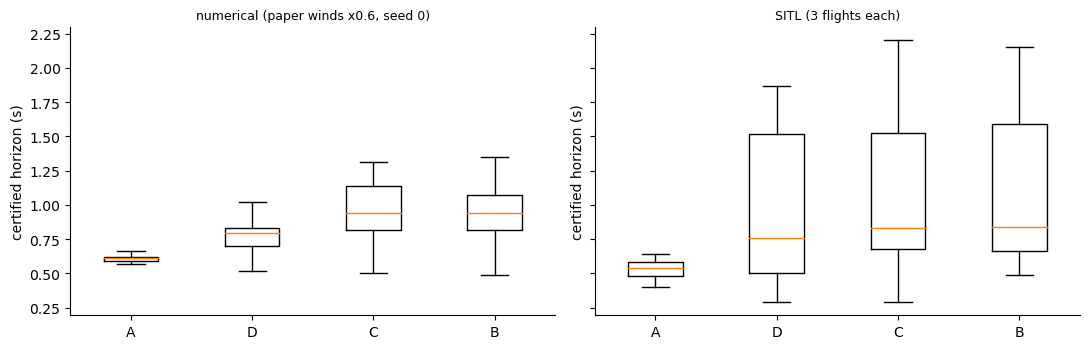

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (label, frame, glob_pat) in zip(axs, (('numerical (paper winds x0.6, seed 0)', num, None), ('SITL (3 flights each)', sitl, None))):
    data = []
    for v in ORDER:
        flights = frame[frame['variant'] == v]['flight']
        vals = []
        for fl in flights:
            path = (f'{DATA}/numerical/{fl}.h5' if label.startswith('num') else f'{DATA}/sitl/{fl}')
            if os.path.exists(path):
                with rta.load(path) as L:
                    t0 = 15.0 if L.metadata.get('platform') != 'numerical_sim' else 0.0
                    vals += [rta.certified_rows(q) * q['dt'] for q in (L.plan(int(s)) for s in L.plan_seqs)
                             if not q.get('warmup', False) and q['t_start'] >= t0]
        data.append(vals if vals else [np.nan])
    ax.boxplot(data, labels=[SHORT[v] for v in ORDER], showfliers=False)
    ax.set_title(label, fontsize=9); ax.set_ylabel('certified horizon (s)')
fig.tight_layout(); fig.savefig('figures/comparison_horizons.pdf'); fig.savefig('figures/comparison_horizons.png', dpi=150)

### Safety: how often, and how far, the vehicle leaves its certified tube

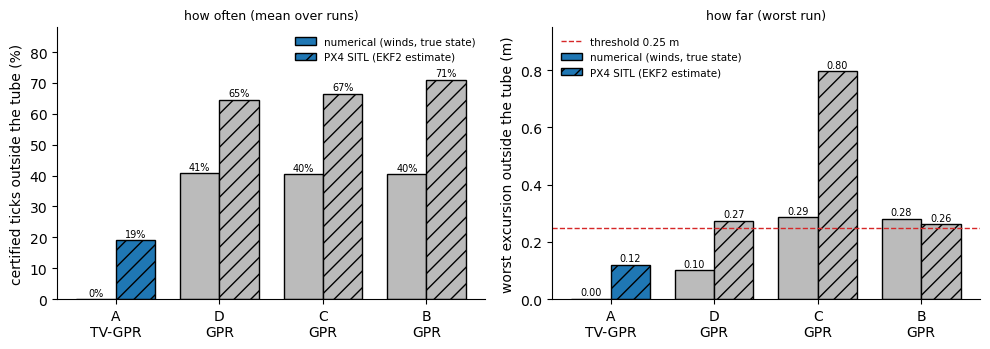

In [13]:
wind = num[num['case'] != 'calm']
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
x = np.arange(len(ORDER)); w = 0.38
colors = ['#1f77b4' if v.startswith('A') else '#bbbbbb' for v in ORDER]
for ax, col, ylabel in ((axs[0], 'escape_pct', 'certified ticks outside the tube (%)'),
                        (axs[1], 'escape_max_m', 'worst excursion outside the tube (m)')):
    agg = 'mean' if col == 'escape_pct' else 'max'
    n_vals = [getattr(wind[wind['variant'] == v][col], agg)() for v in ORDER]
    s_vals = [getattr(sitl[sitl['variant'] == v][col], agg)() for v in ORDER]
    fmt = '%.0f%%' if col == 'escape_pct' else '%.2f'
    ax.bar_label(ax.bar(x - w / 2, n_vals, w, color=colors, edgecolor='k', label='numerical (winds, true state)'),
                 fmt=fmt, fontsize=7, padding=1)
    ax.bar_label(ax.bar(x + w / 2, s_vals, w, color=colors, edgecolor='k', hatch='//', label='PX4 SITL (EKF2 estimate)'),
                 fmt=fmt, fontsize=7, padding=1)
    ax.set_xticks(x, [SHORT[v] + ('\nTV-GPR' if v.startswith('A') else '\nGPR') for v in ORDER])
    ax.set_ylabel(ylabel)
    if col == 'escape_max_m':
        ax.axhline(0.25, color='tab:red', ls='--', lw=1, label='threshold 0.25 m')
    ax.legend(frameon=False, fontsize=7.5)
axs[0].set_ylim(0, 88); axs[1].set_ylim(0, 0.95); axs[0].set_title('how often (mean over runs)', fontsize=9); axs[1].set_title('how far (worst run)', fontsize=9)
fig.tight_layout(); fig.savefig('figures/comparison_escapes.pdf'); fig.savefig('figures/comparison_escapes.png', dpi=150)

## Conclusions

**Only the time-varying GP keeps the certificate true.** With the same embedding system (A vs D), the
time-invariant GP produces tubes about 10× thinner and certifies ~35 % further ahead, but it is
*confidently wrong* about a wind that drifts over time: in the numerical wind runs the true state leaves
its certified box on 27-52 % of certified ticks (about 40 % on average), by up to 0.29 m (more than the
0.25 m threshold itself). With TV-GPR the true state never left a certified box (largest excursion 0.9 mm,
the 10 ms Euler stepping of the tube). In calm air all four variants are equivalent.

**SITL shows the same ordering.** The estimate leaves the certified box on 19 % of ticks with TV-GPR
(up to 11 cm, from the planar model's mismatch with the full PX4 vehicle during the fast descent; the
same mismatch affects every variant) against 65-71 % with the GPR (worst excursions 0.26-0.80 m), and TV-GPR tracks
best (RMSE 20 mm lateral, 27 mm vertical). No flight needed the LAND backup at 0.25 m.

**The embedding systems cannot be ranked with an invalid GP.** Among the GPR variants, (68)-(69) has
the smallest excursions and the best tracking, and (64)-(65) coincides with (66)-(67) for this vehicle
(the inputs enter through a constant selector matrix, so $[M_u](K[e]) = ([M_u]K)[e]$). Because all three
GPR certificates are violated, their tube widths do not measure tightness of a valid over-approximation;
a clean embedding comparison needs a valid disturbance model (TV-GPR + each embedding).

**Cost.** One rollout takes 5-10 ms for every variant, far below the ~0.5 s certified horizon.
